# Assignment : 1

To implement a Single Perceptron Neural Network for binary classification using a real dataset(IRIS) and evaluate its performance.

Name : Sujal Panwar

Enrollment no. : A217145025001

Program : MCA (Master of computer application)

Batch : 2025 - 2027

Submited To : Mr Stephen Mall

### 1. Implementation of Single Perceptron Neural Network for Binary Classification using Iris Dataset.

In [6]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Binary classification (Setosa vs Versicolor)
X = X[y != 2]
y = y[y != 2]

# Convert labels to -1 and 1
y = np.where(y == 0, -1, 1)

# Train-test split (FIXED)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Perceptron class
class Perceptron:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.epochs):
            # SHUFFLE DATA (IMPORTANT)
            for i in np.random.permutation(len(X)):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = 1 if linear_output >= 0 else -1

                if y[i] * y_pred <= 0:
                    self.weights += self.lr * y[i] * X[i]
                    self.bias += self.lr * y[i]

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, -1)

# Train model
model = Perceptron()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Accuracy
accuracy = np.mean(predictions == y_test)
print("✅ Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, predictions))

✅ Accuracy: 1.0

Confusion Matrix:
[[12  0]
 [ 0  8]]

Classification Report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## 2. Data Visualization of Iris Dataset

This graph shows the distribution of two classes (Setosa and Versicolor) using selected features. It helps in understanding how the data is spread and whether the classes are linearly separable.

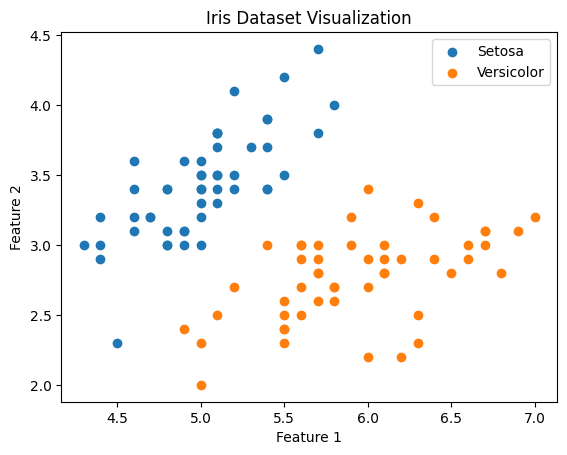

In [2]:
import matplotlib.pyplot as plt

# Use only 2 features for visualization
X_vis = X[:, :2]

plt.scatter(X_vis[y == -1][:, 0], X_vis[y == -1][:, 1], label="Setosa")
plt.scatter(X_vis[y == 1][:, 0], X_vis[y == 1][:, 1], label="Versicolor")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Iris Dataset Visualization")
plt.legend()
plt.show()

## 3. Decision Boundary Visualization of Perceptron Model

This graph illustrates the linear decision boundary learned by the perceptron model. It shows how the model separates the two classes (Setosa and Versicolor) in the feature space using a straight line.

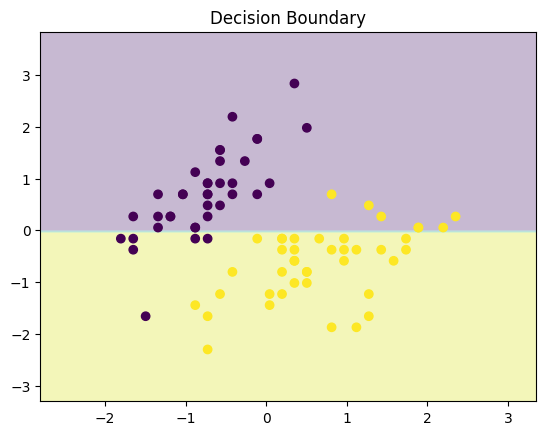

In [3]:
# Decision boundary plot
def plot_decision_boundary(X, y, model):
    X = X[:, :2]  # take 2 features only

    # mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    # Extend to match feature size (hack)
    grid_full = np.zeros((grid.shape[0], X_train.shape[1]))
    grid_full[:, :2] = grid

    Z = model.predict(grid_full)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title("Decision Boundary")
    plt.show()

# Call function
plot_decision_boundary(X_train, y_train, model)

## 4. Confusion Matrix Visualization

This heatmap represents the confusion matrix of the perceptron model. It shows the number of correct and incorrect predictions made by the model for each class, helping to evaluate its performance.

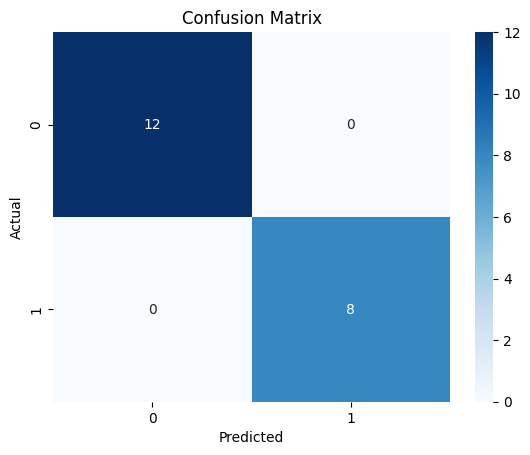

In [4]:
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 5. Model Accuracy Visualization

This bar graph represents the overall accuracy of the perceptron model on the test dataset. It indicates how well the model performs in correctly classifying the data.

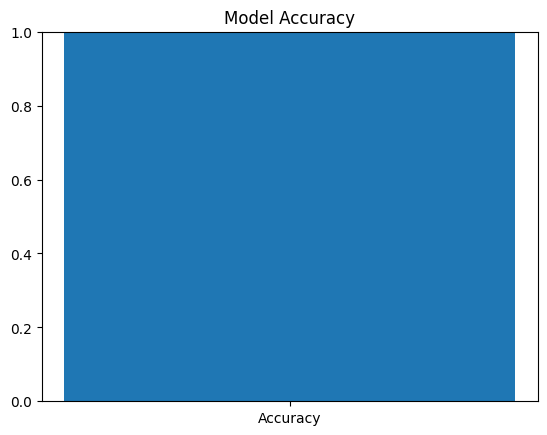

In [5]:
plt.bar(["Accuracy"], [accuracy])
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.show()

## Conclusion

The perceptron model successfully classified the Iris dataset with high accuracy, proving its effectiveness for linearly separable data. However, it is limited to linear problems and may not perform well on complex datasets.